# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "cfc11"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[133.574 134.80457142857142 136.03514285714286 ... 148.85866666666666 152.194 152.194] [133.574 134.80457142857142 136.03514285714286 ... 152.93599999999998 152.194 152.194] [133.574 134.80457142857145 136.03514285714286 ... 152.936 152.194 152.194] [133.574 135.79109090909094 138.0081818181818 ... 152.93599999999998 152.194 152.194] [133.574 134.80457142857142 136.03514285714286 ... 152.34418181818182 152.194 152.194] [133.574 134.80457142857142 136.03514285714286 ... 151.16054545454546 152.194 152.194]] [[134.805 135.67557142857143 136.54614285714285 ... 146.92233333333334 149.934 149.934] [134.805 135.67557142857143 136.54614285714285 ... 150.91899999999998 149.934 149.934] [134.805 135.67557142857143 136.54614285714285 ... 150.919 149.934 149.934] [134.805 136.65852272727275 138.51204545454544 ... 150.91899999999998 149.934 149.934] [134.805 135.67557142857143 136.54614285714285 ... 150.35129545454546 149.934 149.934] [134.805 135.67557142857143 136.54614285714285 ... 149.21588636363634 149.934 149.934]] [[136.151 136.72314285714285 137.2952857142857 ... 145.65733333333333 148.408 148.408] [136.151 136.72314285714288 137.2952857142857 ... 149.4145 148.408 148.408] [136.151 136.72314285714285 137.29528571428574 ... 149.4145 148.408 148.408] [136.151 137.68109090909093 139.2111818181818 ... 149.4145 148.408 148.408] [136.151 136.72314285714288 137.2952857142857 ... 148.90718181818178 148.408 148.408] [136.151 136.72314285714288 137.2952857142857 ... 147.89254545454546 148.408 148.408]] ... [[215.358 215.4999 215.4315 ... 216.4105 216.437 216.562] [215.358 215.57 215.6912857142857 ... 216.4666666666667 216.51433333333333 216.562] [215.358 215.5209411764706 215.63482352941176 ... 216.432 216.63 216.562] [215.358 215.45719047619045 215.55638095238095 ... 216.4114285714286 216.58175 216.562] [215.358 215.3597 215.37509523809524 ... 216.3631785714286 216.5335 216.562] [215.358 215.4298 215.3614 ... 216.3149285714286 216.48525 216.562]] [[215.105 215.105 215.047 ... 216.2975 216.288 216.305] [215.105 215.105 215.2525714285714 ... 216.19366666666667 216.24933333333334 216.305] [215.105 215.105 215.16286666666664 ... 216.379 216.63 216.305] [215.105 215.105 215.047 ... 216.34671428571428 216.5445 216.305] [215.105 215.105 215.047 ... 216.26121428571432 216.459 216.305] [215.105 215.105 215.047 ... 216.1757142857143 216.3735 216.305]] [[214.75 214.75 214.76850000000002 ... 216.1355 216.175 216.27] [214.75 214.75 214.92214285714286 ... 216.06 216.16500000000002 216.27] [214.75 214.75 214.85203333333334 ... 216.151 216.45 216.27] [214.75 214.75 214.76850000000002 ... 216.17314285714286 216.38125 216.27] [214.75 214.75 214.76850000000002 ... 216.10439285714287 216.3125 216.27] [214.75 214.75 214.7685 ... 216.03564285714288 216.24375000000003 216.27]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[133.574 134.80457142857142 136.03514285714286 ... 148.85866666666666 152.194 152.194] [133.574 134.80457142857142 136.03514285714286 ... 152.93599999999998 152.194 152.194] [133.574 134.80457142857145 136.03514285714286 ... 152.936 152.194 152.194] [133.574 135.79109090909094 138.0081818181818 ... 152.93599999999998 152.194 152.194] [133.574 134.80457142857142 136.03514285714286 ... 152.34418181818182 152.194 152.194] [133.574 134.80457142857142 136.03514285714286 ... 151.16054545454546 152.194 152.194]] [[134.805 135.67557142857143 136.54614285714285 ... 146.92233333333334 149.934 149.934] [134.805 135.67557142857143 136.54614285714285 ... 150.91899999999998 149.934 149.934] [134.805 135.67557142857143 136.54614285714285 ... 150.919 149.934 149.934] [134.805 136.65852272727275 138.51204545454544 ... 150.91899999999998 149.934 149.934] [134.805 135.67557142857143 136.54614285714285 ... 150.35129545454546 149.934 149.934] [134.805 135.67557142857143 136.54614285714285 ... 149.21588636363634 149.934 149.934]] [[136.151 136.72314285714285 137.2952857142857 ... 145.65733333333333 148.408 148.408] [136.151 136.72314285714288 137.2952857142857 ... 149.4145 148.408 148.408] [136.151 136.72314285714285 137.29528571428574 ... 149.4145 148.408 148.408] [136.151 137.68109090909093 139.2111818181818 ... 149.4145 148.408 148.408] [136.151 136.72314285714288 137.2952857142857 ... 148.90718181818178 148.408 148.408] [136.151 136.72314285714288 137.2952857142857 ... 147.89254545454546 148.408 148.408]] ... [[215.358 215.4999 215.4315 ... 216.4105 216.437 216.562] [215.358 215.57 215.6912857142857 ... 216.4666666666667 216.51433333333333 216.562] [215.358 215.5209411764706 215.63482352941176 ... 216.432 216.63 216.562] [215.358 215.45719047619045 215.55638095238095 ... 216.4114285714286 216.58175 216.562] [215.358 215.3597 215.37509523809524 ... 216.3631785714286 216.5335 216.562] [215.358 215.4298 215.3614 ... 216.3149285714286 216.48525 216.562]] [[215.105 215.105 215.047 ... 216.2975 216.288 216.305] [215.105 215.105 215.2525714285714 ... 216.19366666666667 216.24933333333334 216.305] [215.105 215.105 215.16286666666664 ... 216.379 216.63 216.305] [215.105 215.105 215.047 ... 216.34671428571428 216.5445 216.305] [215.105 215.105 215.047 ... 216.26121428571432 216.459 216.305] [215.105 215.105 215.047 ... 216.1757142857143 216.3735 216.305]] [[214.75 214.75 214.76850000000002 ... 216.1355 216.175 216.27] [214.75 214.75 214.92214285714286 ... 216.06 216.16500000000002 216.27] [214.75 214.75 214.85203333333334 ... 216.151 216.45 216.27] [214.75 214.75 214.76850000000002 ... 216.17314285714286 216.38125 216.27] [214.75 214.75 214.76850000000002 ... 216.10439285714287 216.3125 216.27] [214.75 214.75 214.7685 ... 216.03564285714288 216.24375000000003 216.27]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'cfc11' (lon: 6, lat: 12, year: 46, month: 12)> Size: 318kB
<Quantity([[[[145.838      147.089      147.993      ... 154.263
    155.382      156.137     ]
   [155.999      155.384      155.098      ... 158.54
    158.935      159.388     ]
   [159.808      160.056      160.483      ... 168.06
    168.184      167.592     ]
   ...
   [222.172      221.901      221.472      ... 220.341
    220.281      220.248     ]
   [220.046      219.812      219.541      ... 218.362
    218.234      218.15      ]
   [217.946      217.667      217.287      ... 215.781
    215.659      215.288     ]]

  [[144.2944     145.6644     146.7398     ... 152.7096
    153.8806     154.8128    ]
   [154.9986     154.705      154.5458     ... 157.9356
    158.4952     159.1064    ]
   [159.6316     159.9736     160.44       ... 167.1774
    167.4342     167.1616    ]
...
   [223.56591667 223.43616667 223.38233333 ... 221.043
    221.1095     221.2995    ]
   [221.18558333 221.019      220.84441667 ... 218.99333333
    219.02775    218.90766667]
   [218.82325    218.6865     218.42541667 ... 216.30033333
    216.3155     216.41216667]]

  [[158.602      158.697      158.763      ... 166.162
    167.722      168.177     ]
   [168.464      168.645      168.829      ... 172.447
    174.314      175.51      ]
   [176.189      176.569      176.584      ... 180.515
    181.818      183.012     ]
   ...
   [223.9745     223.817      223.6885     ... 221.4655
    221.6295     221.73      ]
   [221.584      221.3865     221.205      ... 219.18
    219.3525     219.0415    ]
   [218.9435     218.859      218.717      ... 216.1565
    216.2965     216.454     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 368B 1978 1979 1980 1981 1982 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[145.838 147.089 147.993 ... 215.781 215.659 215.288] [144.2944 145.6644 146.7398 ... 215.8615 215.58075 215.4151] [142.7508 144.2398 145.4866 ... 215.67950000000002 215.42975 215.2875] ... [155.11366666666666 155.366 155.55766666666668 ... 216.442 216.4545 216.3825] [158.602 158.697 158.763 ... 216.236 216.311 216.403] [158.602 158.697 158.763 ... 216.31925 216.40025 216.5335]] [[145.838 147.089 147.993 ... 215.781 215.659 215.288] [144.2944 145.6644 146.7398 ... 215.94899999999998 215.60499999999996 215.49999999999997] [142.7508 144.2398 145.4866 ... 216.09642857142856 215.77057142857143 215.678] ... [155.825 156.213 156.82449999999997 ... 216.81466666666668 216.67733333333334 216.70166666666668] [158.602 158.697 158.763 ... 216.64833333333334 216.59066666666666 216.65733333333333] [158.602 158.697 158.763 ... 216.482 216.504 216.613]] [[145.838 147.089 147.993 ... 215.781 215.659 215.288] [144.29440000000002 145.6644 146.7398 ... 215.895 215.6710909090909 215.45454545454544] [144.14785714285713 145.52814285714285 146.69507142857142 ... 215.955 215.7492727272727 215.57563636363633] ... [155.82500000000002 156.21300000000002 156.8245 ... 216.1585 216.3015 216.3185] [158.602 158.697 158.763 ... 216.431 216.663 216.84] [158.602 158.697 158.763 ... 216.1565 216.29649999999998 216.454]] [[145.838 147.089 147.993 ... 215.781 215.659 215.288] [146.90977272727272 148.06936363636365 148.95252272727274 ... 215.989125 215.86206249999998 215.55825000000002] [147.98154545454545 149.04972727272727 149.91204545454545 ... 216.19725000000003 216.065125 215.82850000000002] ... [155.82500000000002 156.21300000000002 156.8245 ... 217.027 216.56 216.566] [158.602 158.697 158.763 ... 216.42899999999997 216.3245 216.4305] [158.602 158.697 158.763 ... 215.831 216.089 216.295]] [[145.838 147.089 147.993 ... 215.781 215.659 215.288] [144.2944 145.66440000000003 146.7398 ... 215.6865 215.53225 215.24530000000001] [144.93483333333333 146.171 147.141 ... 215.69956249999998 215.55828125 215.316625] ... [156.16604545454547 156.5137272727273 157.02029545454545 ... 216.83199999999997 216.5248333333333 216.50483333333332] [158.602 158.697 158.763 ... 216.36466666666666 216.32000000000002 216.42133333333334] [158.602 158.697 158.763 ... 215.99374999999998 216.19275 216.37449999999998]] [[145.838 147.089 147.993 ... 215.781 215.659 215.288] [144.2944 145.6644 146.7398 ... 215.77400000000003 215.55650000000003 215.3302] [142.7508 144.2398 145.4866 ... 215.59199999999998 215.40550000000002 215.2026] ... [156.84813636363637 157.1151818181818 157.41188636363637 ... 216.63699999999997 216.48966666666666 216.44366666666667] [158.602 158.697 158.763 ... 216.30033333333333 216.3155 216.41216666666665] [158.602 158.697 158.763 ... 216.1565 216.29649999999998 216.454]]]
Units,ppt


### Longitudinal-mean

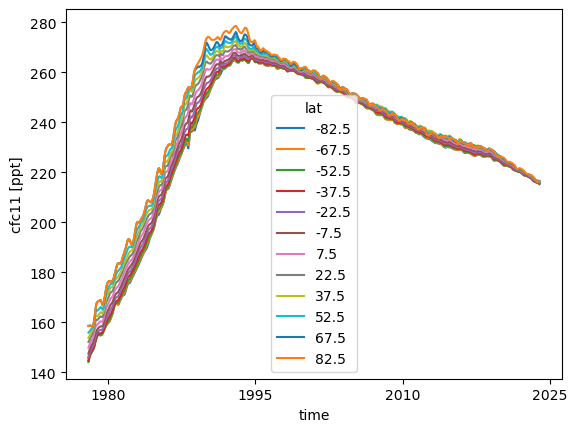

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

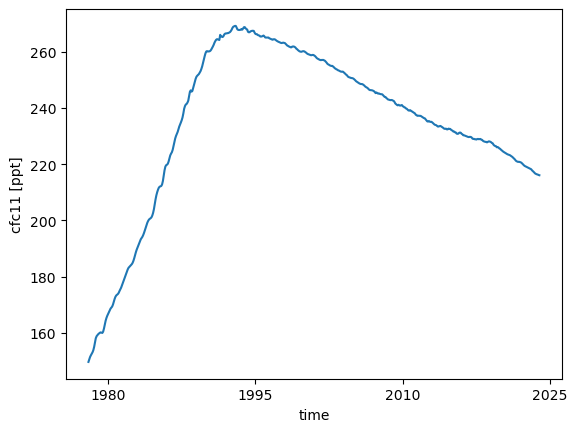

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

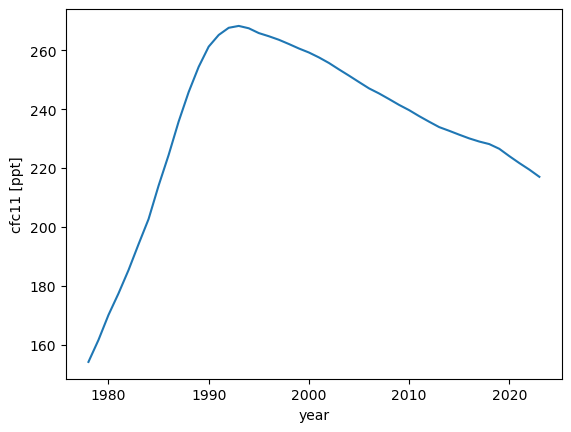

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 6kB
Dimensions:               (lat: 12, eof: 12, year: 46)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 368B 1978 1979 1980 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.3546 ... -0.05329
    principal-components  (year, eof) float64 4kB [] -15.39 1.348 ... 8.923e-14

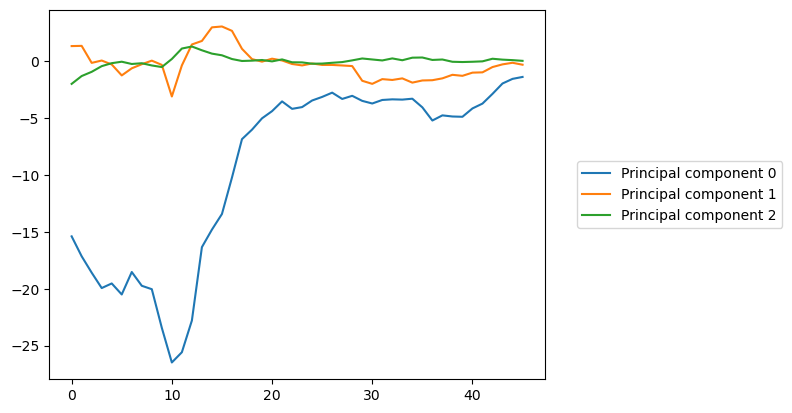

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

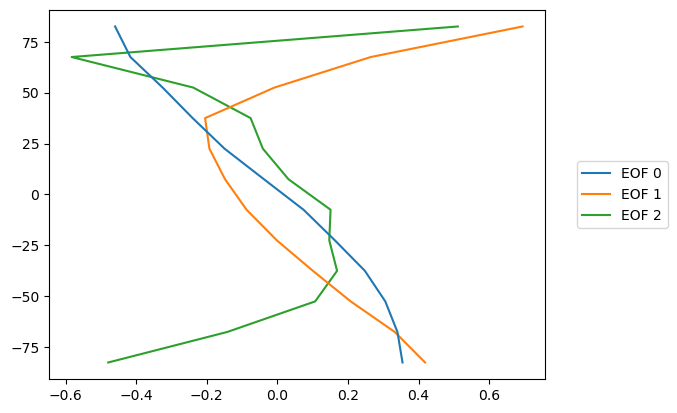

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

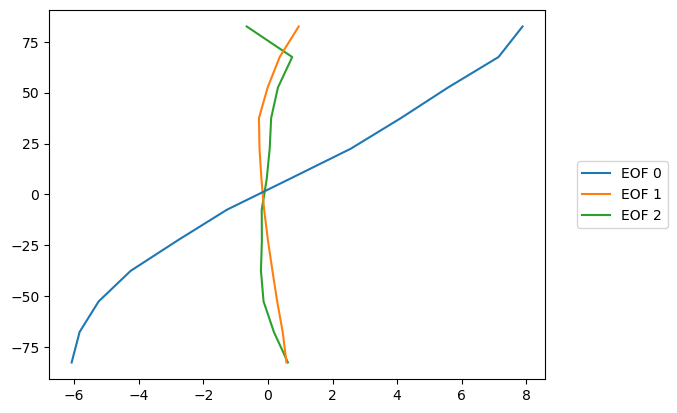

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.35457134084471065] [0.34017109403181706] [0.3057552686629882] [0.24798986978253523] [0.16286741944963082] [0.0742371001117359] [-0.038099540997515974] [-0.14958331251074003] [-0.23989285227702267] [-0.3249539723150721] [-0.41626530690749436] [-0.45966659114842867]]
Units,ppt
Magnitude,[[-15.38722224489184] [-17.13962417799606] [-18.58132747827533] [-19.93496862468553] [-19.529276594437214] [-20.49875698565313] [-18.523058951127037] [-19.73414498277203] [-20.034392344097828] [-23.435376305910097] [-26.480455406366715] [-25.5807885048736] [-22.791865148278003] [-16.336333574071332] [-14.795246016463283] [-13.419900341132445] [-10.21559436835749] [-6.836441449539192] [-6.002201036477729] [-5.004951036150819] [-4.374909935300897] [-3.5165770376205723] [-4.172027338010557] [-4.017564105647128] [-3.4373182933406055] [-3.1227656309869096] [-2.7473504061697414] [-3.3010419551152332] [-3.025941164156592] [-3.4701703261630064] [-3.7011973333810184] [-3.390846822933555] [-3.336063048654696] [-3.3594704118634913] [-3.280234549845362] [-4.038925371602385] [-5.198240166785303] [-4.745652948249058] [-4.844512992857529] [-4.86999855359832] [-4.13546871149015] [-3.709884715456702] [-2.8546335802306224] [-1.9415071834609097] [-1.5349871218229976] [-1.3655351484259468]]
Units,dimensionless


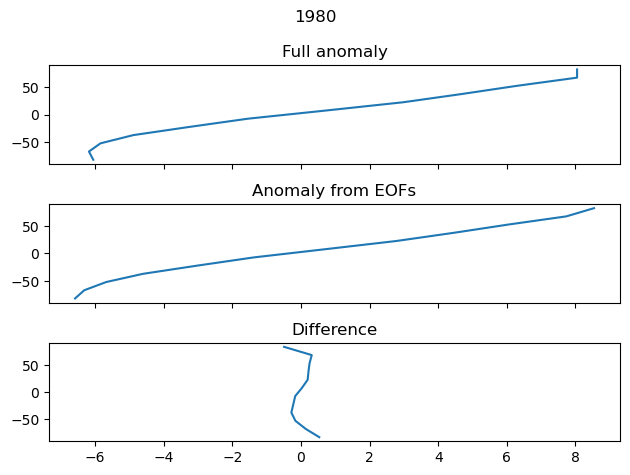

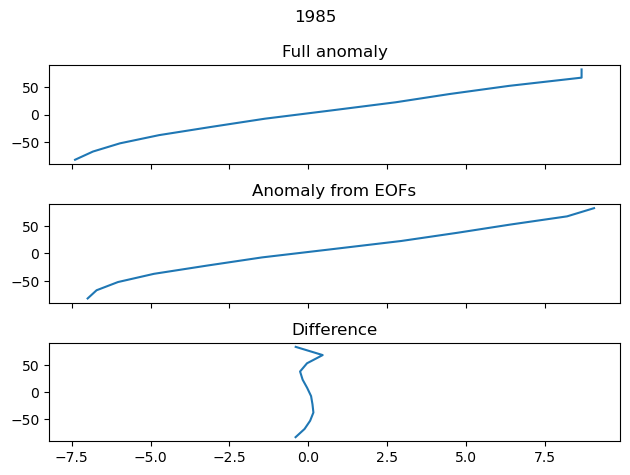

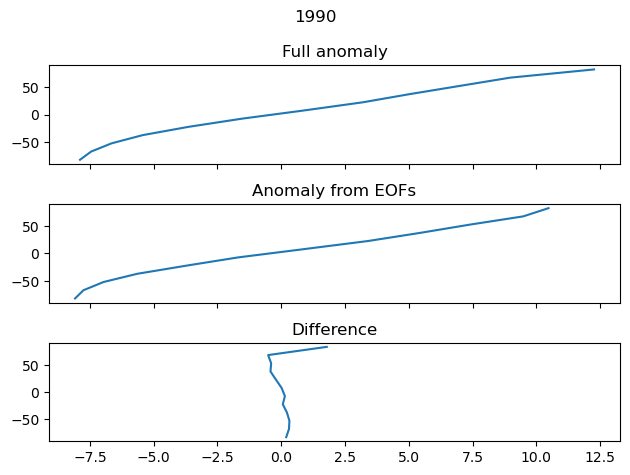

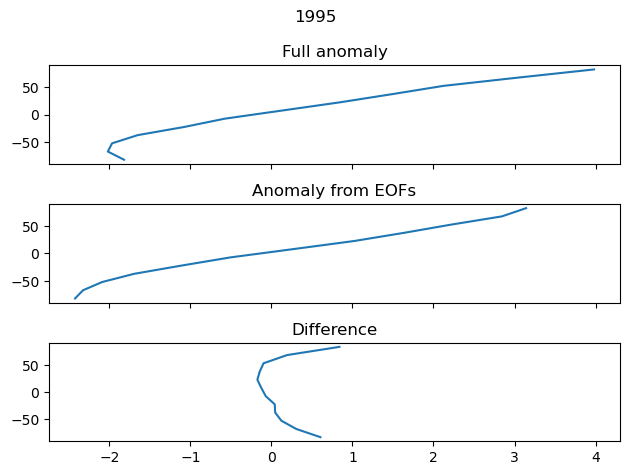

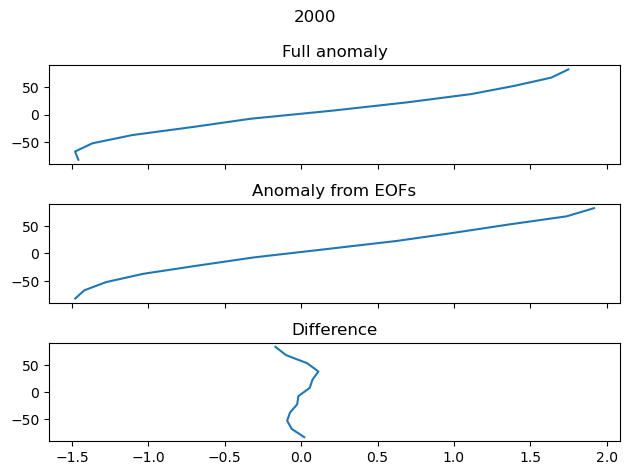

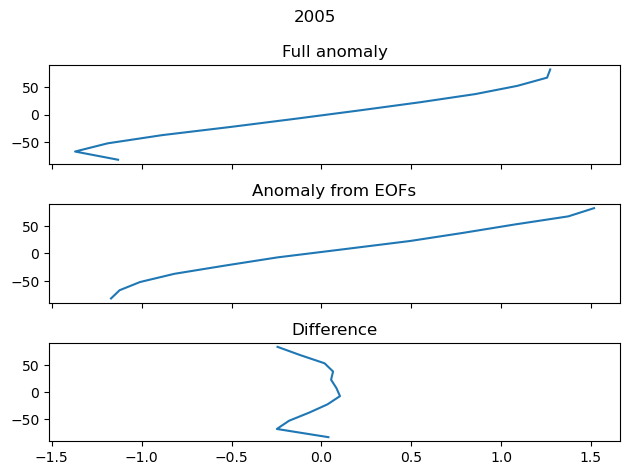

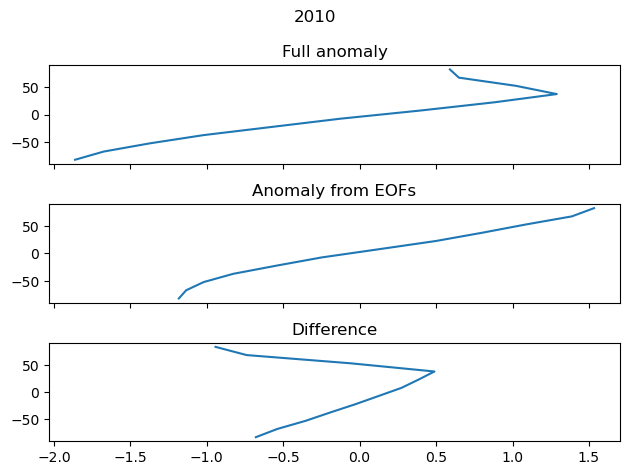

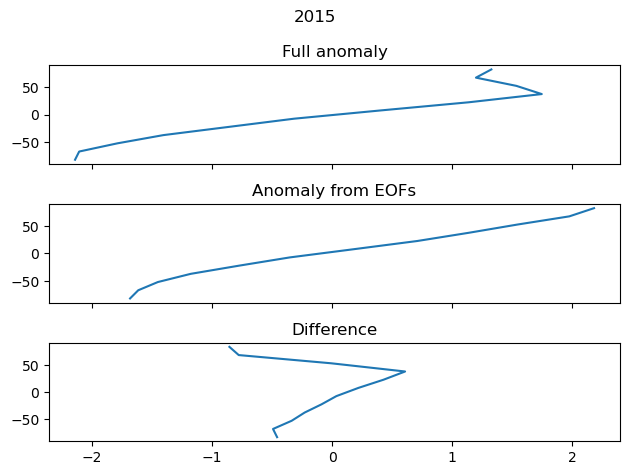

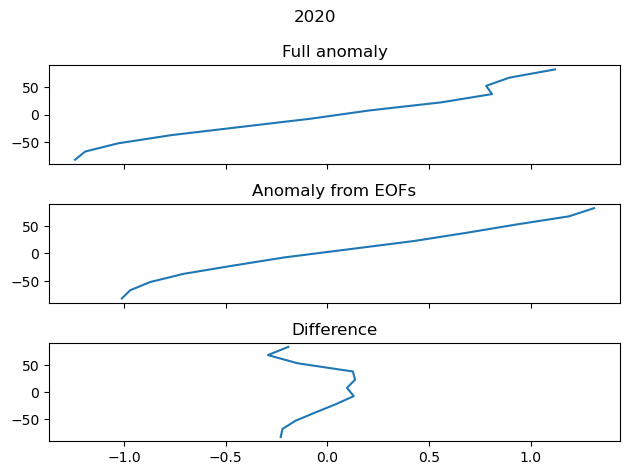

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/552 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 552/552 [00:00<00:00, 18977.51it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/552 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/552 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 552/552 [00:00<00:00, 19593.91it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/552 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 552/552 [00:00<00:00, 19218.84it/s]

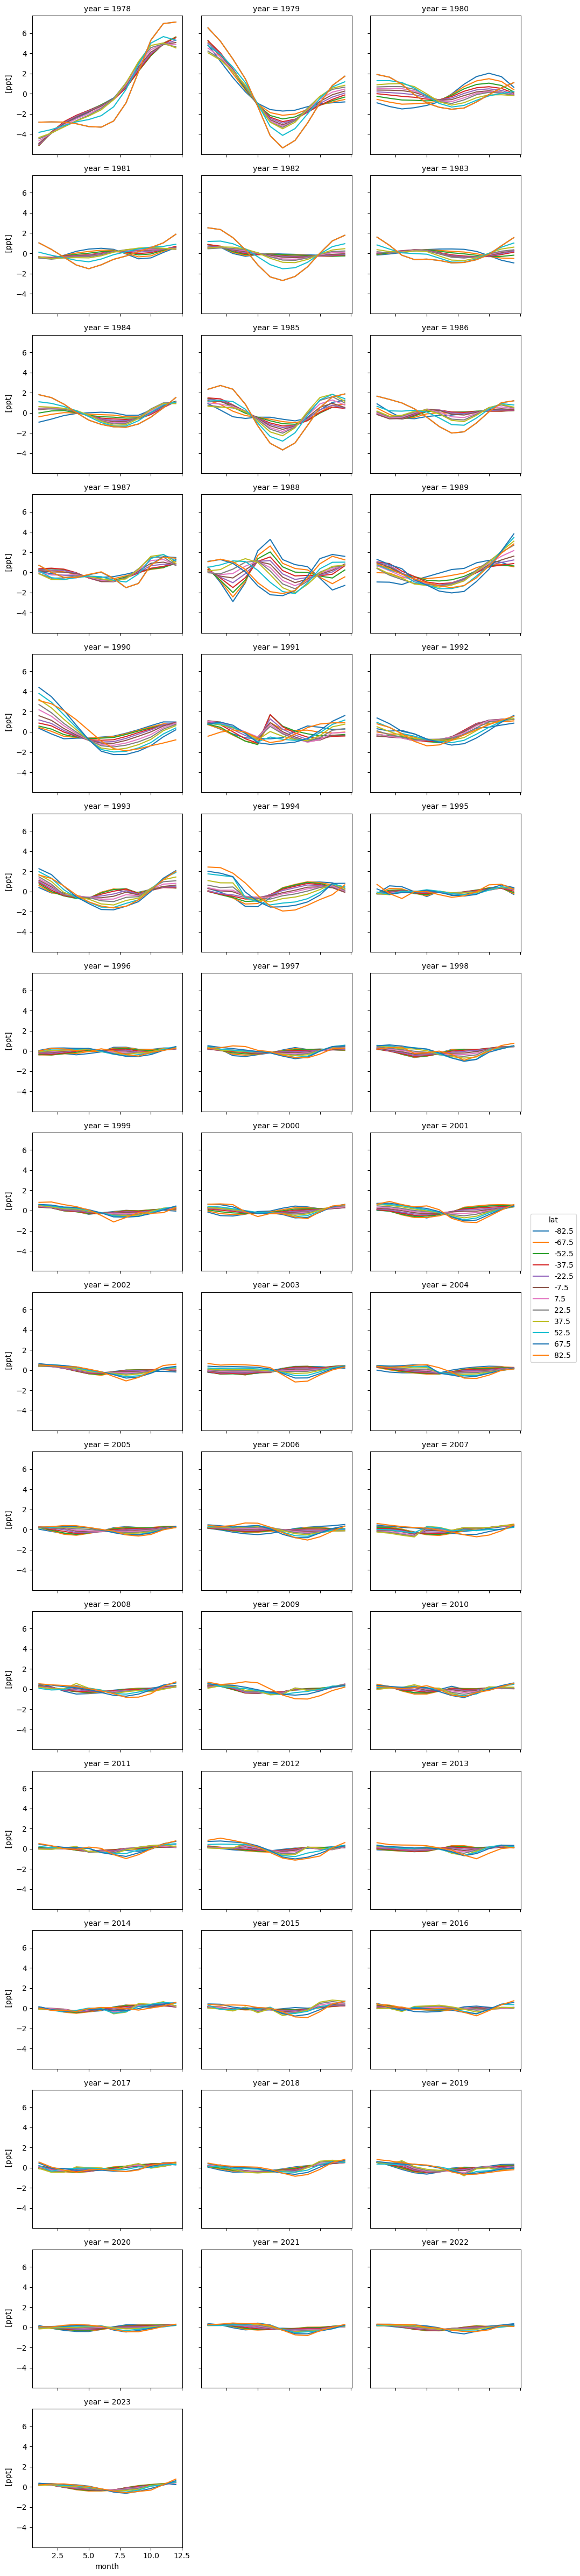

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

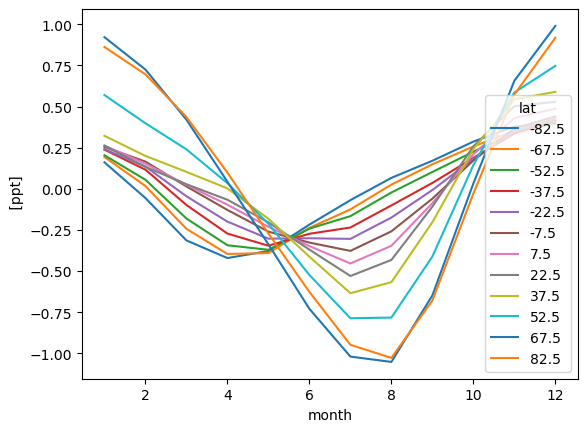

In [22]:
seasonality.plot.line(hue="lat")

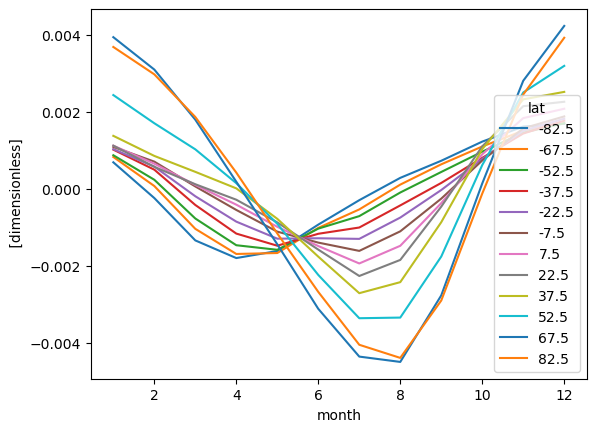

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[154.1660490302408 161.61624396416718 170.1161832915636 177.427602685421 185.35114393230256 194.12951971853082 202.67365355779245 214.01884737942933 224.41014013016274 235.76692198171614 245.79188118157376 254.36035109941793 261.22536833286523 265.19338288279863 267.6264264578443 268.260806087671 267.4617050999245 265.8318401873432 264.76224299500774 263.56315897918154 262.12020426639725 260.60136276425516 259.2373106647686 257.5694410099016 255.67698835715143 253.49261088083094 251.37985419633858 249.20069799037103 247.05545798331033 245.33224598549285 243.41720867131644 241.44401796074953 239.66378170695634 237.63163709504363 235.73347333413673 233.90561164082987 232.6491697006335 231.331203455438 230.06821248934284 229.0020757747363 228.13794725083196 226.53517456197378 224.04878984507573 221.6883455344173 219.46850184572153 217.01981307693347]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.35457134084471065] [0.34017109403181706] [0.3057552686629882] [0.24798986978253523] [0.16286741944963082] [0.0742371001117359] [-0.038099540997515974] [-0.14958331251074003] [-0.23989285227702267] [-0.3249539723150721] [-0.41626530690749436] [-0.45966659114842867]]
Units,ppt
Magnitude,[[-15.38722224489184] [-17.13962417799606] [-18.58132747827533] [-19.93496862468553] [-19.529276594437214] [-20.49875698565313] [-18.523058951127037] [-19.73414498277203] [-20.034392344097828] [-23.435376305910097] [-26.480455406366715] [-25.5807885048736] [-22.791865148278003] [-16.336333574071332] [-14.795246016463283] [-13.419900341132445] [-10.21559436835749] [-6.836441449539192] [-6.002201036477729] [-5.004951036150819] [-4.374909935300897] [-3.5165770376205723] [-4.172027338010557] [-4.017564105647128] [-3.4373182933406055] [-3.1227656309869096] [-2.7473504061697414] [-3.3010419551152332] [-3.025941164156592] [-3.4701703261630064] [-3.7011973333810184] [-3.390846822933555] [-3.336063048654696] [-3.3594704118634913] [-3.280234549845362] [-4.038925371602385] [-5.198240166785303] [-4.745652948249058] [-4.844512992857529] [-4.86999855359832] [-4.13546871149015] [-3.709884715456702] [-2.8546335802306224] [-1.9415071834609097] [-1.5349871218229976] [-1.3655351484259468]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.0006867198035720173 -0.0002407986546879546 -0.0013397728409737743 -0.0017976624233308107 -0.0016151936671304171 -0.0009296122345307179 -0.00029580695601898475 0.00028303837532836897 0.0007269678653758088 0.0012238612963325986 0.0016141472670893639 0.0016841157022432895] [0.000825334306702429 7.126474180439004e-05 -0.001039273013535241 -0.0016913506835405305 -0.0016670965541381374 -0.001014920629559646 -0.0005357128486295291 0.00010799355036836292 0.0006350173390479359 0.0010967444098752223 0.0015080306784993553 0.001703972538097969] [0.0008702798478027474 0.00023376458204386484 -0.0007712288031351817 -0.001464740265354875 -0.0015832458633572818 -0.0010337747496995723 -0.0007097234397729622 -9.689521645857006e-05 0.00043615878425340513 0.0009621022408887181 0.0014549899146834675 0.0017023167398705996] [0.0010154212951898384 0.0004957908281624551 -0.00042030711541531074 -0.0011626689554028972 -0.0014773419576315937 -0.0011675575394470487 -0.0010051728216423496 -0.0004315808696186059 0.00015157016304519295 0.000801948076362046 0.0014333918670670462 0.001766510725938123] [0.001028922271812372 0.0005762550714655682 -0.0001939587900066133 -0.0008526241371234407 -0.0012944470741542754 -0.0012841030357459693 -0.0012999265673172703 -0.0007472283864692135 -3.230775259445807e-05 0.0007750162763387887 0.0015075181647553572 0.0018168875985191844] [0.0010866232279000128 0.000704304377546876 6.03346818677662e-05 -0.0005492469501599399 -0.0011122269532900253 -0.00139654503750496 -0.0016116269320050219 -0.0011041067303922526 -0.0002558560640700493 0.0007339742219212301 0.0015672334199837532 0.0018771423207540403] [0.001118968159882324 0.0006507728357750868 0.00010087214661478011 -0.0004122648334530027 -0.0009868220062618472 -0.0014859279630522683 -0.0019377459569738828 -0.0014794632968051493 -0.0003724475645107296 0.0008942654916995518 0.0018333925129669381 0.00207640395221492] [0.0011188512460748765 0.0005692950361439557 0.00011780841615048216 -0.0002840288453813727 -0.0008720746333785014 -0.0015783927087118137 -0.002262721286918998 -0.0018461759129892374 -0.0004637294091370665 0.0011010434871238984 0.0021427132612556123 0.0022574147787544673] [0.0013734257235605406 0.0008525970159607594 0.00043915604980951514 1.066989452182914e-05 -0.0007795139053610524 -0.0017609485455177243 -0.002708848931436579 -0.0024229167078817036 -0.0008671102954567217 0.0010289389423434223 0.002320606344834695 0.002513947909657884] [0.0024315951395618867 0.0017002104849826898 0.001023337739730162 0.00014522503167636216 -0.0009087174641386496 -0.002235772579242161 -0.003358583425835628 -0.0033420779978016314 -0.0017583446589029812 0.0006158559586910117 0.0024982763984830996 0.003188999050609448] [0.003933731829806754 0.0030932843453017832 0.0017929812032256459 0.0001825471680737426 -0.001440956481492152 -0.0031150436323825895 -0.004354245950949936 -0.004492468435856309 -0.002766565774787075 0.00013855218301669036 0.002802701708423904 0.004225485861827012] [0.0036794518827772456 0.002969330301043917 0.0018628089689436376 0.00041972380756974203 -0.0011594116401021234 -0.0026760886151311453 -0.004047487875437869 -0.004387950182573563 -0.002899535385826017 -0.00012440073710068817 0.002445385913068587 0.003918178357439633]]
Units,dimensionless
